# Bayesian neural networks from scratch

## Goal
Learn how a diagonal Gaussian weight posterior, reparameterized samples and the evidence lower bound (ELBO) fit together in PyTorch. This is a corrected, modular adaptation of `im_rl.ipynb`, cell 12.

The example predicts a noisy sine function. It is an introductory inference tutorial, not an industrial optimizer or a claim of calibrated uncertainty. The code lives in [`bnn_from_scratch.py`](bnn_from_scratch.py); existing Pyro and decision-optimization notebooks provide the next step.

## Setup
From the repository root, install `python -m pip install -r requirements-tutorial.txt` and open this notebook. It runs from either the root or `notebooks/`. No external data, downloads or credentials are needed.

### Assumptions
- 100 independent training and 100 independent test points with inputs uniform on [-3, 3].
- Truth: `y = sin(x) + Normal(0, 0.3²)`; the observation noise is treated as known.
- Gaussian prior and mean-field Gaussian posterior; no full posterior covariance.
- Full-batch training, 1,000 updates, three weight draws per update, fixed seed 42.
- The test set is used only after training, not for model selection.

In [1]:
from pathlib import Path
import sys
import platform
import numpy as np
import torch
import matplotlib.pyplot as plt

module_dir = Path.cwd() if (Path.cwd() / 'bnn_from_scratch.py').exists() else Path.cwd() / 'notebooks'
sys.path.insert(0, str(module_dir))
from bnn_from_scratch import BayesianNeuralNetwork, make_data, fit, predictive_moments

torch.manual_seed(42)
torch.set_num_threads(1)
plt.rcParams.update({'figure.figsize': (10, 4.5), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Python {platform.python_version()}, PyTorch {torch.__version__}, NumPy {np.__version__}')
x_train, y_train, x_test, y_test = make_data(seed=42)
model = BayesianNeuralNetwork(hidden_dim=20, prior_sigma=1.0)
print(f'Training rows: {len(x_train)}; held-out rows: {len(x_test)}')

Python 3.14.2, PyTorch 2.10.0, NumPy 2.4.2
Training rows: 100; held-out rows: 100


## Steps
### 1. Weight sampling and the normalized ELBO
Each weight is sampled as $w=\mu+\mathrm{softplus}(\rho)\epsilon$, where $\epsilon\sim N(0,1)$. The implementation computes the exact Gaussian $KL(q\Vert p)$ and uses

$$L= -\frac{1}{SB}\sum_{s=1}^S\sum_{i=1}^B \log p(y_i\mid x_i,w_s) + \frac{KL(q\Vert p)}{N}.$$

Here $N$ is the full training size and $B$ is the batch size. Output dimensions are summed inside each observation. The likelihood is evaluated **for each weight sample before averaging**. KL is added once at the matching per-row scale. No likelihood is computed from an averaged prediction.

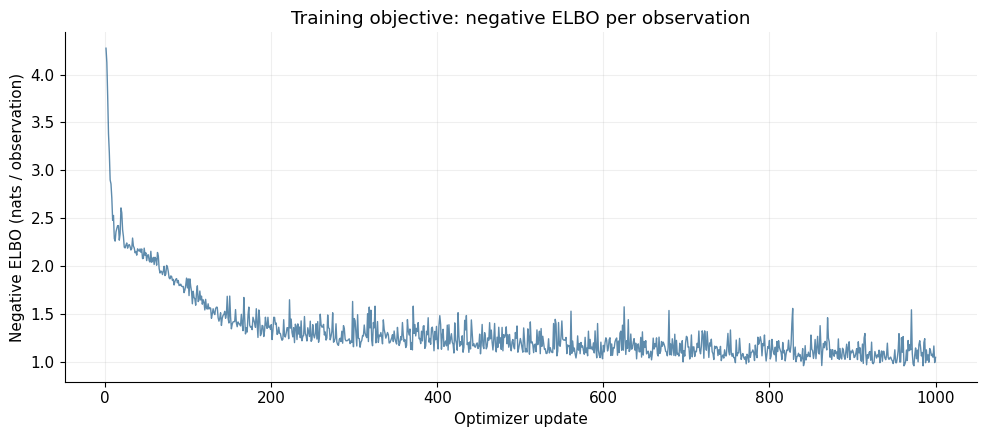

Mean objective, first 50 updates: 2.431
Mean objective, final 50 updates: 1.093


In [2]:
history = fit(model, x_train, y_train, steps=1000, num_samples=3, noise_std=0.3)
assert np.isfinite(history).all()
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(history) + 1), history, color='#286491', linewidth=1, alpha=0.75)
ax.set(title='Training objective: negative ELBO per observation', xlabel='Optimizer update', ylabel='Negative ELBO (nats / observation)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f'Mean objective, first 50 updates: {np.mean(history[:50]):.3f}')
print(f'Mean objective, final 50 updates: {np.mean(history[-50:]):.3f}')

The objective is a Monte Carlo estimate, so individual updates need not decrease. Training loss alone does not establish generalization or interval calibration.

### 2. Separate uncertainty in the function from observation noise
Across posterior weight samples, the function mean and variance describe epistemic uncertainty under the fitted approximation. Total predictive variance adds the known observation variance, `0.3²`. The bands below are **mean ± 2 standard deviations**, not guaranteed 95% coverage intervals. The outer parts of the plot, outside [-3, 3], are extrapolation.

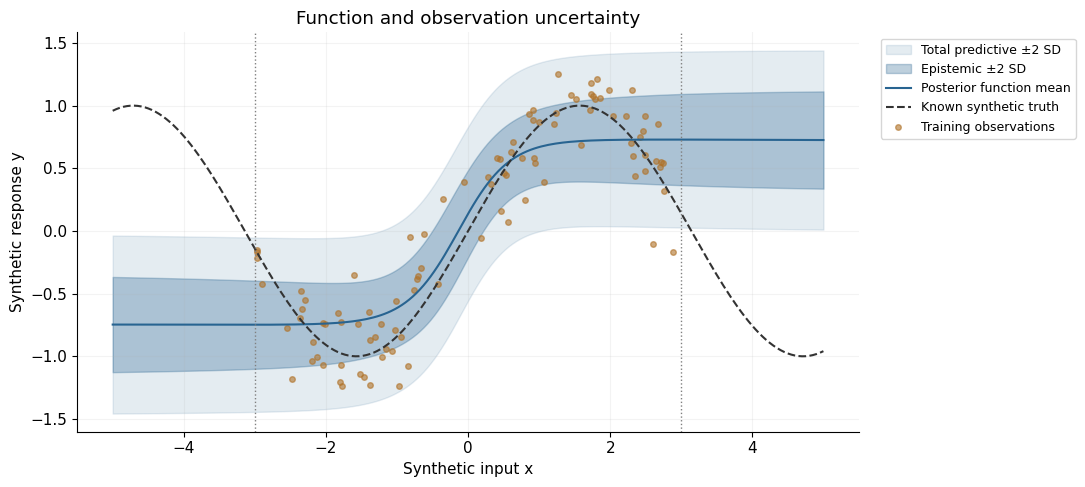

In [3]:
torch.manual_seed(2026)
x_grid = torch.linspace(-5, 5, 200).reshape(-1, 1)
mean, epistemic_var, total_var = predictive_moments(model, x_grid, num_samples=500, noise_std=0.3)
x = x_grid[:, 0].numpy()
mu = mean[:, 0].numpy()
epi = epistemic_var[:, 0].sqrt().numpy()
total = total_var[:, 0].sqrt().numpy()
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(x, mu - 2 * total, mu + 2 * total, color='#286491', alpha=0.12, label='Total predictive ±2 SD')
ax.fill_between(x, mu - 2 * epi, mu + 2 * epi, color='#286491', alpha=0.3, label='Epistemic ±2 SD')
ax.plot(x, mu, color='#286491', label='Posterior function mean')
ax.plot(x, np.sin(x), color='#333333', linestyle='--', label='Known synthetic truth')
ax.scatter(x_train[:, 0], y_train[:, 0], color='#b07228', s=16, alpha=0.6, label='Training observations')
ax.axvline(-3, color='gray', linestyle=':', linewidth=1)
ax.axvline(3, color='gray', linestyle=':', linewidth=1)
ax.set(title='Function and observation uncertainty', xlabel='Synthetic input x', ylabel='Synthetic response y')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## Checks
The tests reconcile analytic KL with PyTorch distributions, check per-sample likelihood averaging and minibatch scaling, and verify gradients and the variance decomposition. Run `python -m pytest -q` from the repository root.

The following held-out metrics describe this particular synthetic run. Coverage on only 100 test observations is a diagnostic; it does not demonstrate universal calibration. Test data remain within [-3, 3], so these numbers do not validate extrapolation.

In [4]:
torch.manual_seed(2027)
test_mean, test_epistemic, test_total = predictive_moments(model, x_test, 500, 0.3)
rmse = ((test_mean - y_test).square().mean()).sqrt().item()
coverage = ((y_test - test_mean).abs() <= 2 * test_total.sqrt()).float().mean().item()
assert torch.isfinite(test_mean).all()
torch.testing.assert_close(test_total - test_epistemic, torch.full_like(test_total, 0.09))
print(f'Held-out RMSE: {rmse:.3f}')
print(f'Held-out mean ±2 total-SD coverage: {coverage:.1%} ({len(x_test)} observations)')
print(f'Mean epistemic variance: {test_epistemic.mean().item():.4f}')
print('Known observation variance: 0.0900')

Held-out RMSE: 0.350
Held-out mean ±2 total-SD coverage: 94.0% (100 observations)
Mean epistemic variance: 0.0280
Known observation variance: 0.0900


## Next Steps
Repeat over data and training seeds before comparing inference quality. Compare with the existing Pyro implementation and a deterministic network; examine interval coverage across input regions. For industrial decisions, pass posterior scenarios into the inventory or production examples and evaluate decision cost separately from prediction error.

This tutorial corrects four issues in the source cell: likelihood averaging, KL normalization, sample-dependent KL bookkeeping, and omission of observation noise from total predictive uncertainty. Tensor operations also preserve model device and dtype.